=== Reporte de Clasificación Random Forest ===
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       147
           1       0.95      0.98      0.97       100
           2       0.98      0.96      0.97       130
           3       0.96      0.98      0.97       138
           4       1.00      0.98      0.99       142
           5       0.97      0.91      0.94        67
           6       0.97      0.98      0.98       107
           7       0.98      0.94      0.96        63
           8       0.96      0.96      0.96       106

    accuracy                           0.97      1000
   macro avg       0.97      0.96      0.97      1000
weighted avg       0.97      0.97      0.97      1000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Jugada óptima sugerida (RF): 2


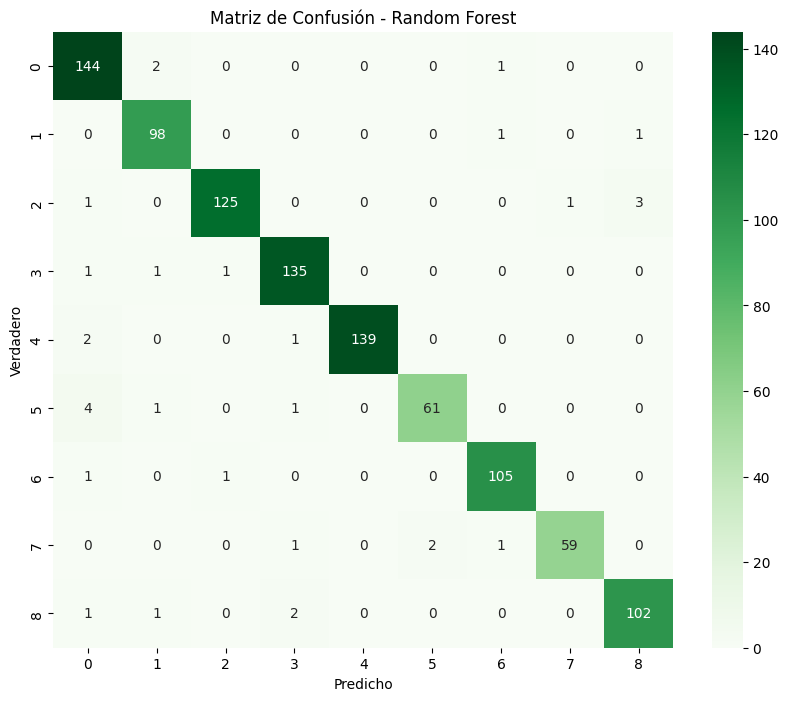

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# FASE 1: SELECCIÓN DE DATOS (Data Selection)
# ==========================================
url = "https://raw.githubusercontent.com/Hohemhein03/Dataset-Tic-Tac-Toe/refs/heads/main/dataset.csv"
raw = requests.get(url).text
raw_clean = raw.replace('"', '') # Limpieza inicial de formato
df = pd.read_csv(StringIO(raw_clean), header=None)

# Definir nombres de columnas: 9 del tablero, 1 turno, 1 target
df.columns = [f"pos_{i}" for i in range(0, 9)] + ["turn", "best_move"]

# ==========================================
# FASE 2: PREPROCESAMIENTO (Preprocessing)
# ==========================================
# Convertimos los datos categóricos a numéricos para que el algoritmo los entienda
mapping_tablero = {"X": 1, "O": -1, "_": 0, "b": 0} # Estandarización
mapping_turno = {"X": 1, "O": -1}

# Aplicar mapeo a las columnas del tablero
for col in [f"pos_{i}" for i in range(0, 9)]:
    df[col] = df[col].map(mapping_tablero).fillna(0)

# Aplicar mapeo al turno
df["turn"] = df["turn"].map(mapping_turno).fillna(1) # Asumimos 1 si hay error

# Asegurar que el target sea entero
df["best_move"] = df["best_move"].astype(int)

# ==========================================
# FASE 3: TRANSFORMACIÓN (Transformation)
# ==========================================
X = df.drop(columns=["best_move"])
y = df["best_move"]

# División 80% entrenamiento, 20% prueba (Estándar en investigación)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# FASE 4: MINERÍA DE DATOS (Data Mining)
# ==========================================
# Algoritmo: Random Forest (Clasificación Supervisada)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# ==========================================
# FASE 5: INTERPRETACIÓN Y EVALUACIÓN (Evaluation)
# ==========================================
y_pred = rf.predict(X_test)

# --- MÉTRICAS PARA TU INFORME (Punto 3.4) ---
print("=== Reporte de Clasificación Random Forest ===")
print(classification_report(y_test, y_pred)) # Copia esto para tu tabla de resultados

# --- GRÁFICO MATRIZ DE CONFUSIÓN (Punto 3) ---
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.savefig('confusion_matrix_rf.png') # Guarda la imagen para tu documento
# plt.show() # Descomentar si quieres verla en pantalla

# ==========================================
# IMPLEMENTACIÓN FINAL (Uso del Modelo)
# ==========================================
def predecir_jugada(tablero, turno):
    """
    Recibe lista de 9 elementos y el turno ('X' o 'O')
    """
    t_num = [mapping_tablero.get(x, 0) for x in tablero]
    s_num = mapping_turno.get(turno, 1)

    # Crear vector de entrada (10 características)
    entrada = np.array(t_num + [s_num]).reshape(1, -1)
    prediccion = rf.predict(entrada)[0]
    return prediccion

# Ejemplo Final
ejemplo = ["X","X","_", "_","O","O", "_","_","_"]
turno_actual = "X"
print(f"Jugada óptima sugerida (RF): {predecir_jugada(ejemplo, turno_actual)}")